# Desafío Técnico Artefact: Segmentación de Clientes E-commerce B2C

**Objetivo de Negocio:** Analizar el comportamiento de los visitantes del sitio web (datos de Google Analytics) para identificar segmentos de usuarios. Esto permitirá al equipo de marketing diseñar campañas personalizadas y mejorar la retención.

## Carga de Datos y Sanity Check
El primer paso en nuestro flujo de trabajo es importar los datos, verificar su estructura general y confirmar la integridad del dataset (búsqueda de valores nulos o tipos de datos incorrectos).

In [17]:
# Importar librerías base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

# Carga del dataset
df = pd.read_csv('data_customers.csv')

# Sanity Check
print("--- PRIMERAS 5 FILAS ---")
display(df.head())

print("\n--- INFORMACIÓN DEL DATASET ---")
df.info()

print("\n--- CONTEO DE VALORES NULOS ---")
print(df.isnull().sum())

--- PRIMERAS 5 FILAS ---


,fullVisitorId,channelGrouping,weekend_prop,hour,sessionId,device.browser,device.deviceCategory,device.isMobile,device.operatingSystem,totals.hits,totals.pageviews,bounce_prop,trafficSource.medium
0,213131142648941,Direct,0.000000,22.0,1,Chrome,desktop,0.0,Macintosh,14.0,13.0,0.0,(none)
1,435324061339869,Referral,0.666667,21.0,3,Chrome,desktop,0.0,Macintosh,14.0,11.0,0.0,referral
2,562678147042735,Organic Search,0.000000,14.0,2,Chrome,desktop,0.0,Macintosh,12.5,10.5,0.0,organic
3,585708896049892,Referral,0.000000,20.0,1,Chrome,desktop,0.0,Linux,22.0,20.0,0.0,referral
4,670722016498267,Referral,0.000000,17.0,2,Chrome,desktop,0.0,Linux,9.5,9.5,0.0,referral



--- INFORMACIÓN DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fullVisitorId           9996 non-null   uint64 
 1   channelGrouping         9996 non-null   str    
 2   weekend_prop            9996 non-null   float64
 3   hour                    9996 non-null   float64
 4   sessionId               9996 non-null   int64  
 5   device.browser          9996 non-null   str    
 6   device.deviceCategory   9996 non-null   str    
 7   device.isMobile         9996 non-null   float64
 8   device.operatingSystem  9996 non-null   str    
 9   totals.hits             9996 non-null   float64
 10  totals.pageviews        9996 non-null   float64
 11  bounce_prop             9996 non-null   float64
 12  trafficSource.medium    9996 non-null   str    
dtypes: float64(6), int64(1), str(5), uint64(1)
memory usage: 1015.3 KB

---

**Conclusiones del Sanity Check:**
* **Integridad:** El dataset cuenta con 9,996 registros y 13 variables. No existen valores nulos.
* **Tipos de datos:** Los formatos son congruentes, pero la variable `fullVisitorId` es un identificador único numérico (`uint64`). No aporta valor analítico al comportamiento del usuario, por lo que la moveremos al índice del dataframe para no sesgar el algoritmo, pero sin perder la trazabilidad de los clientes.

## Análisis Exploratorio de Datos (EDA)
El objetivo de esta fase es comprender el comportamiento natural de nuestras variables. 
1. Analizaremos las distribuciones numéricas para detectar valores atípicos (outliers) en las interacciones.
2. Evaluaremos la composición de nuestro tráfico categórico.
3. Revisaremos las correlaciones matemáticas para prevenir redundancias de información antes de alimentar nuestro algoritmo de clustering.

--- FORMA DEL DATASET ---
Filas: 9996, Columnas: 12



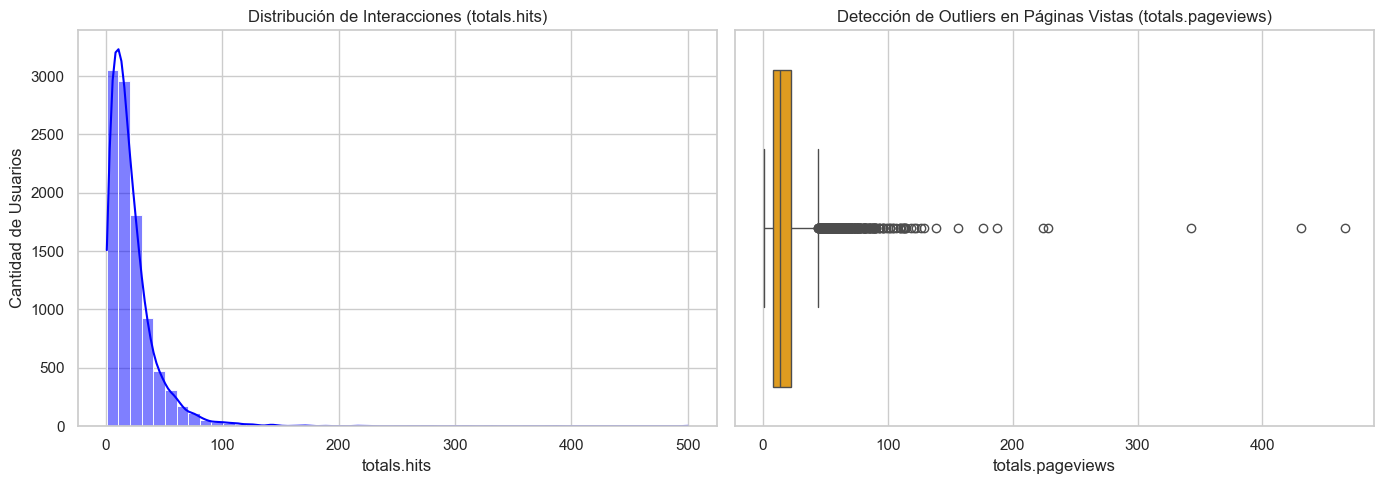

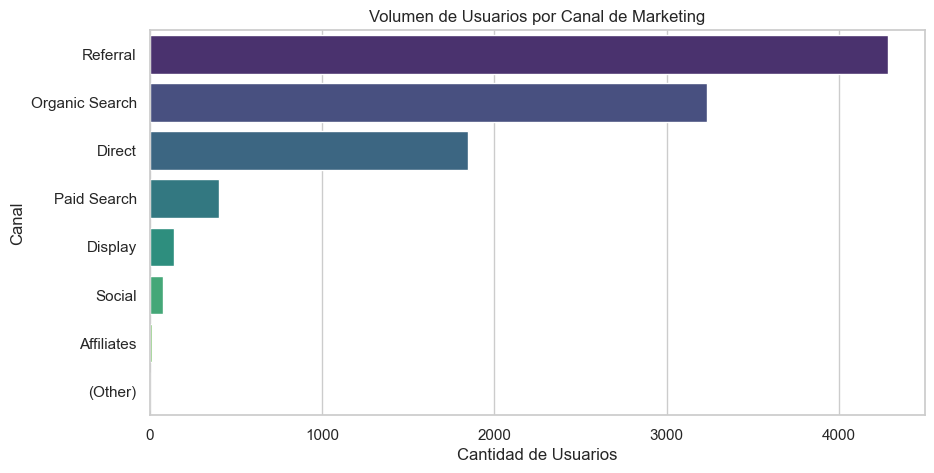

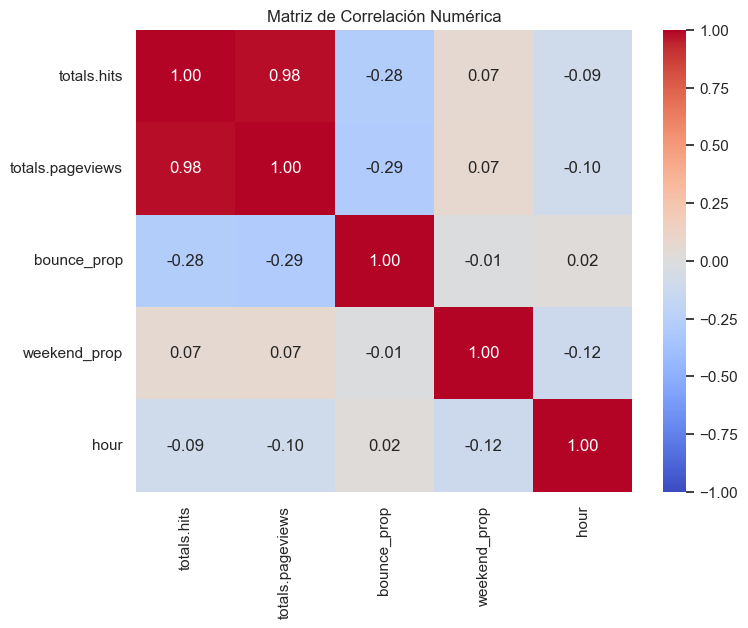

In [19]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual para gráficas
sns.set_theme(style="whitegrid")

# Corrección estricta: Asegurar que el ID esté en el índice antes del EDA
if 'fullVisitorId' in df.columns:
    df = df.set_index('fullVisitorId')

print("--- FORMA DEL DATASET ---")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

# 1. Análisis Univariado Numérico (Buscando Outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['totals.hits'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribución de Interacciones (totals.hits)')
axes[0].set_ylabel('Cantidad de Usuarios')

sns.boxplot(x=df['totals.pageviews'], ax=axes[1], color='orange')
axes[1].set_title('Detección de Outliers en Páginas Vistas (totals.pageviews)')

plt.tight_layout()
plt.show()

# 2. Análisis Categórico
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df, 
    y='channelGrouping', 
    order=df['channelGrouping'].value_counts().index, 
    palette='viridis'
)
plt.title('Volumen de Usuarios por Canal de Marketing')
plt.xlabel('Cantidad de Usuarios')
plt.ylabel('Canal')
plt.show()

# 3. Correlación inicial de variables numéricas
cols_num = ['totals.hits', 'totals.pageviews', 'bounce_prop', 'weekend_prop', 'hour']
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_num].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación Numérica')
plt.show()



**Conclusiones del Análisis Exploratorio (EDA):**

1. **Distribución de Interacciones (Hits):** El histograma revela una asimetría positiva extrema. La inmensa mayoría de los usuarios realiza muy pocas interacciones, mientras que una minoría se extiende en una larga cola hacia la derecha.
2. **Outliers en Páginas Vistas (Pageviews):** El boxplot confirma visualmente la asimetría y evidencia una gran concentración de valores atípicos en la parte superior. En un e-commerce, estos "outliers" no son errores de registro, sino clientes de alto valor (heavy users). No debemos eliminarlos, pero requerirán una transformación (como Yeo-Johnson) para comprimir su escala y no sesgar la varianza del modelo.
3. **Volumen por Canales (Channel Grouping):** Los canales `Referral` y `Organic Search` dominan abrumadoramente el tráfico del sitio. Esto sugiere que el flujo principal proviene de enlaces externos (afiliados/recomendaciones) y usuarios con intención de búsqueda activa.
4. **Matriz de Correlación:** Detectamos una multicolinealidad crítica (**0.98**) entre `totals.hits` y `totals.pageviews`. Ambas variables miden prácticamente la misma dimensión de comportamiento en la sesión. 

**Decisión Estratégica para el Modelo:** En algoritmos basados en distancia (K-Means), incluir variables altamente correlacionadas distorsiona el espacio geométrico al darle un "doble peso" a una misma característica. Por lo tanto, conservaremos `totals.pageviews` y descartaremos `totals.hits` antes del escalado.

## Preprocesamiento y Feature Engineering
Con base en la evidencia de nuestro Análisis Exploratorio, prepararemos el espacio matemático para el algoritmo K-Means:

1. **Limpieza de Identificadores:** Eliminamos `sessionId` ya que es un identificador técnico que no representa un comportamiento de navegación. Nuestro `fullVisitorId` ya está protegido en el índice del dataset.
2. **Manejo de Multicolinealidad:** Descartamos `totals.hits` (correlación 0.98) para evitar sobredimensionar la métrica de interacción en el cálculo de distancias.
3. **Transformación de Sesgo:** Comprimimos los outliers de `totals.pageviews` usando la transformación Yeo-Johnson, manteniendo a nuestros clientes de alto valor sin que monopolicen la varianza.
4. **Codificación Espacial (One-Hot):** Binarizamos las variables categóricas. Mantendremos todas las categorías (`drop_first=False`) para garantizar que la distancia euclidiana sea simétrica para todos los atributos.
5. **Estandarización:** Escalamos todas las dimensiones (`StandardScaler`) para que contribuyan equitativamente a la formación del clúster.

In [20]:
from sklearn.preprocessing import StandardScaler, PowerTransformer

# 1. Copiamos el dataframe en memoria y eliminamos el ID de sesión
df_clean = df.drop(columns=['sessionId']).copy()

# 2. LA DECISIÓN DE LA MATRIZ DE CORRELACIÓN
# Eliminamos 'totals.hits' por su alta redundancia con pageviews
df_clean = df_clean.drop(columns=['totals.hits'])

# 3. LA DECISIÓN DE LOS OUTLIERS
# Comprimimos matemáticamente las páginas vistas
pt = PowerTransformer(method='yeo-johnson')
df_clean[['totals.pageviews']] = pt.fit_transform(df_clean[['totals.pageviews']])

# 4. Convertir texto a columnas matemáticas (One-Hot Encoding)
cols_categoricas = ['channelGrouping', 'device.browser', 'device.deviceCategory', 
                    'device.operatingSystem', 'trafficSource.medium']

# K-MEANS: drop_first=False 
df_procesado = pd.get_dummies(df_clean, columns=cols_categoricas, drop_first=False)

# 5. Escalamiento Final 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_procesado)

# 6. Reconstrucción del DataFrame (Conservando el índice fullVisitorId)
df_final = pd.DataFrame(X_scaled, columns=df_procesado.columns, index=df_procesado.index)

print("✅ PASO 3 COMPLETADO: Datos limpios, transformados y escalados.")
print(f"La matriz final (df_final) está lista para K-Means con {df_final.shape[1]} columnas.")
print("\n--- VISTA PREVIA DE LA MATRIZ ---")
display(df_final.head(3))

✅ PASO 3 COMPLETADO: Datos limpios, transformados y escalados.
La matriz final (df_final) está lista para K-Means con 39 columnas.

--- VISTA PREVIA DE LA MATRIZ ---


,weekend_prop,hour,device.isMobile,totals.pageviews,bounce_prop,channelGrouping_(Other),channelGrouping_Affiliates,channelGrouping_Direct,channelGrouping_Display,channelGrouping_Organic Search,channelGrouping_Paid Search,channelGrouping_Referral,channelGrouping_Social,device.browser_Amazon Silk,device.browser_Android Webview,device.browser_Chrome,device.browser_Edge,device.browser_Firefox,device.browser_Internet Explorer,device.browser_Opera,device.browser_Safari,device.browser_Safari (in-app),device.deviceCategory_desktop,device.deviceCategory_mobile,device.deviceCategory_tablet,device.operatingSystem_Android,device.operatingSystem_Chrome OS,device.operatingSystem_Linux,device.operatingSystem_Macintosh,device.operatingSystem_Windows,device.operatingSystem_Windows Phone,device.operatingSystem_iOS,trafficSource.medium_(none),trafficSource.medium_(not set),trafficSource.medium_affiliate,trafficSource.medium_cpc,trafficSource.medium_cpm,trafficSource.medium_organic,trafficSource.medium_referral
fullVisitorId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
213131142648941,-0.496316,1.206054,-0.32766,-0.045414,-0.509694,-0.010003,-0.033191,2.098391,-0.119614,-0.691406,-0.204167,-0.866379,-0.086361,-0.010003,-0.024507,0.344233,-0.072314,-0.127946,-0.097954,-0.022371,-0.28006,-0.034669,0.327635,-0.296748,-0.127541,-0.213045,-0.288487,-0.281097,0.89485,-0.498718,-0.010003,-0.234017,2.099784,-0.010003,-0.033191,-0.22336,-0.118316,-0.679581,-0.880439
435324061339869,1.754384,1.046332,-0.32766,-0.248353,-0.509694,-0.010003,-0.033191,-0.476556,-0.119614,-0.691406,-0.204167,1.154229,-0.086361,-0.010003,-0.024507,0.344233,-0.072314,-0.127946,-0.097954,-0.022371,-0.28006,-0.034669,0.327635,-0.296748,-0.127541,-0.213045,-0.288487,-0.281097,0.89485,-0.498718,-0.010003,-0.234017,-0.476240,-0.010003,-0.033191,-0.22336,-0.118316,-0.679581,1.135797
562678147042735,-0.496316,-0.071720,-0.32766,-0.303854,-0.509694,-0.010003,-0.033191,-0.476556,-0.119614,1.446328,-0.204167,-0.866379,-0.086361,-0.010003,-0.024507,0.344233,-0.072314,-0.127946,-0.097954,-0.022371,-0.28006,-0.034669,0.327635,-0.296748,-0.127541,-0.213045,-0.288487,-0.281097,0.89485,-0.498718,-0.010003,-0.234017,-0.476240,-0.010003,-0.033191,-0.22336,-0.118316,1.471494,-0.880439


## Modelado K-Means: Búsqueda del Número Óptimo de Segmentos (K)

Dado que el Clustering es un aprendizaje no supervisado, no tenemos una variable objetivo para medir el error tradicional. Para determinar matemáticamente el número ideal de clústeres (K), utilizaremos dos métricas complementarias:

1. **Método del Codo (Inercia):** Mide la compacidad de los clústeres (suma de distancias al cuadrado desde cada punto a su centroide). Buscamos el punto de inflexión donde añadir un clúster más deja de aportar valor significativo.
2. **Coeficiente de Silueta:** Evalúa la cohesión interna frente a la separación externa de los clústeres. Un valor más cercano a 1 indica clústeres bien definidos y separados. Esta métrica nos dará la respuesta definitiva si el "Codo" es ambiguo.

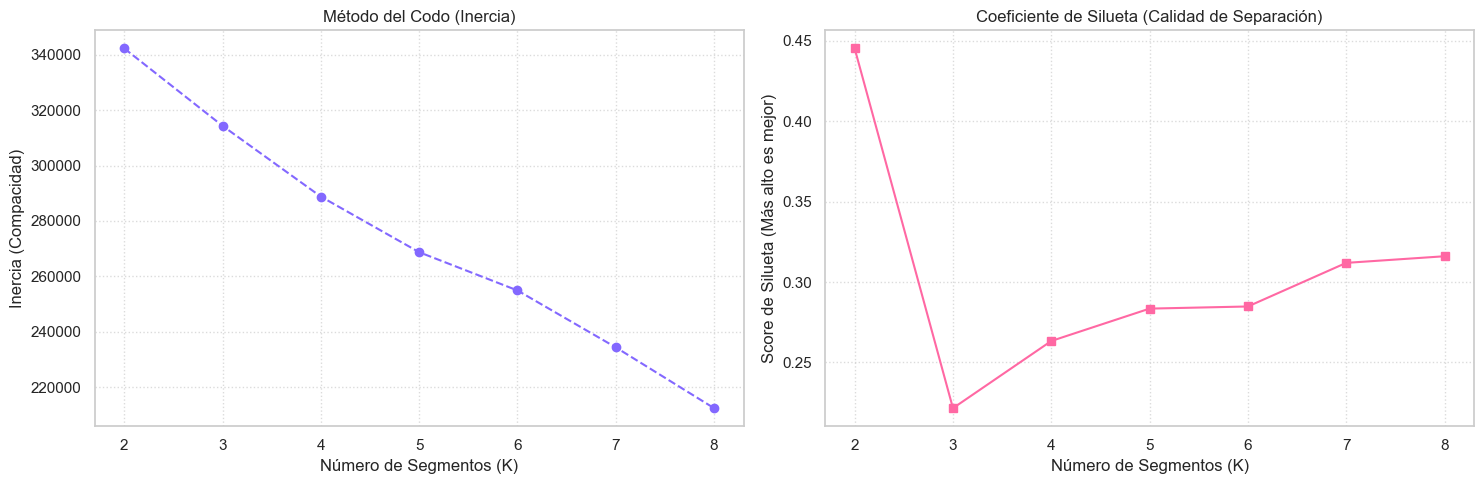

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Listas para guardar las métricas de evaluación
inercias = []
siluetas = []

# Probaremos agrupar a los clientes desde 2 hasta 8 segmentos
# (Detenemos en 8 por eficiencia, más de 8 clústeres en marketing rara vez es accionable)
rango_k = range(2, 9) 

for k in rango_k:
    # n_init=10 asegura que el algoritmo corra 10 veces con distintos centroides iniciales
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenamos y asignamos clústeres temporalmente
    clusters_temp = kmeans.fit_predict(df_final)
    
    # 1. Guardamos la Inercia (Codo)
    inercias.append(kmeans.inertia_)
    
    # 2. Guardamos el Score de Silueta
    silueta_promedio = silhouette_score(df_final, clusters_temp)
    siluetas.append(silueta_promedio)

# --- VISUALIZACIÓN DE MÉTRICAS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Método del Codo
axes[0].plot(rango_k, inercias, marker='o', linestyle='--', color='#8368FF')
axes[0].set_title('Método del Codo (Inercia)')
axes[0].set_xlabel('Número de Segmentos (K)')
axes[0].set_ylabel('Inercia (Compacidad)')
axes[0].set_xticks(rango_k)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Gráfico 2: Coeficiente de Silueta
axes[1].plot(rango_k, siluetas, marker='s', linestyle='-', color='#FF68A3')
axes[1].set_title('Coeficiente de Silueta (Calidad de Separación)')
axes[1].set_xlabel('Número de Segmentos (K)')
axes[1].set_ylabel('Score de Silueta (Más alto es mejor)')
axes[1].set_xticks(rango_k)
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

**Conclusiones de la Búsqueda de K:**
1. **Análisis de Inercia (Codo):** La curva no presenta un ángulo agudo perfecto, pero observamos que la reducción de la varianza interna comienza a estabilizarse a partir de $K=5$. Añadir un sexto clúster aportaría una mejora marginal.
2. **Análisis de Silueta:** El pico máximo se encuentra en $K=2$ (~0.45). Matemáticamente, K-Means encuentra muy fácil dividir este dataset de 40 dimensiones en solo dos mitades (probablemente separando una variable binaria dominante). Sin embargo, un segmento binario carece de utilidad para una estrategia de E-commerce. Los scores para $K=3$ caen drásticamente por debajo de 0.20, lo cual es un síntoma clásico de la *Maldición de la Dimensionalidad* causada por el One-Hot Encoding masivo.

**Decisión Estratégica:** Rechazaremos el $K=2$ por ser comercialmente inútil. Basándonos en el punto de inflexión visual de la Inercia, configuraremos nuestro modelo base en **$K=5$** para intentar descubrir cinco "buyer personas" distintas, conscientes de que la penalización por alta dimensionalidad requerirá una revisión profunda de los resultados.

In [22]:
# 1. Instanciamos y entrenamos el modelo final con K=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)

# 2. Asignamos las etiquetas de los clústeres al dataset original limpio
# Usamos df_clean (que tiene los textos originales de las categorías para poder leerlos)
df_clean['Cluster_KMeans'] = kmeans_final.fit_predict(df_final)

# 3. PERFILADO DE NEGOCIO
print("--- TAMAÑO DE LOS SEGMENTOS (K=5) ---")
display(df_clean['Cluster_KMeans'].value_counts().to_frame(name='Usuarios'))

print("\n--- PERFILADO NUMÉRICO (Medianas y Medias) ---")
# Usamos la mediana para pageviews porque sigue teniendo asimetría en el mundo real
# Usamos la media para porcentajes (prop) y horas
perfil_num = df_clean.groupby('Cluster_KMeans').agg({
    'totals.pageviews': 'median',
    'bounce_prop': 'mean',
    'weekend_prop': 'mean',
    'hour': 'mean'
}).round(2)
display(perfil_num)

print("\n--- PERFILADO CATEGÓRICO (La Moda / Lo más frecuente) ---")
# Extraemos el valor más repetido (la moda) de las categorías clave en cada clúster
perfil_cat = df_clean.groupby('Cluster_KMeans')[['channelGrouping', 'device.deviceCategory', 'device.operatingSystem']].agg(lambda x: x.mode()[0])
display(perfil_cat)

--- TAMAÑO DE LOS SEGMENTOS (K=5) ---


,Usuarios
Cluster_KMeans,
0,4339
4,2950
3,1603
2,963
1,141



--- PERFILADO NUMÉRICO (Medianas y Medias) ---


,totals.pageviews,bounce_prop,weekend_prop,hour
Cluster_KMeans,,,,
0,-0.05,0.08,0.11,15.06
1,-0.05,0.08,0.05,16.65
2,-0.05,0.17,0.26,12.36
3,0.05,0.08,0.12,15.26
4,0.21,0.07,0.18,13.69



--- PERFILADO CATEGÓRICO (La Moda / Lo más frecuente) ---


,channelGrouping,device.deviceCategory,device.operatingSystem
Cluster_KMeans,,,
0,Referral,desktop,Macintosh
1,Display,desktop,Macintosh
2,Organic Search,mobile,iOS
3,Direct,desktop,Macintosh
4,Organic Search,desktop,Macintosh


## Interpretación de Clústeres (K-Means) y Decisiones de Negocio

El modelo de K-Means (K=5) nos ha devuelto los siguientes segmentos:

1. **Clúster 0 (4,339 usuarios - "Tráfico Referido Desktop"):** Es el segmento más grande. Llegan a través de enlaces externos (Referral), navegan en Mac/Desktop alrededor de las 15:00 hrs. Su interacción en páginas es ligeramente inferior al promedio (-0.05).
2. **Clúster 4 (2,950 usuarios - "Orgánicos de Alto Valor"):** Usuarios captados por búsquedas orgánicas (Desktop/Mac). Son el segmento con **mayor interacción** (0.21 en pageviews transformados) y la tasa de rebote más baja (7%). Son el objetivo ideal para estrategias de fidelización.
3. **Clúster 3 (1,603 usuarios - "Directos Desktop"):** Tráfico que teclea la URL directamente. Comportamiento estándar, interactuando principalmente a media tarde (15:26 hrs).
4. **Clúster 2 (963 usuarios - "El Segmento Móvil/Fin de Semana"):** El único clúster dominado por móviles (iOS). Tienen la **tasa de rebote más alta (17%)** y la mayor proporción de navegación en fines de semana (26%). *Acción:* La experiencia móvil requiere optimización urgente para reducir ese rebote.
5. **Clúster 1 (141 usuarios - "Nicho Display"):** Un micro-segmento captado exclusivamente por anuncios gráficos (Display). Tienen comportamiento promedio, pero un volumen demasiado bajo para justificar grandes presupuestos.

**💡 Reflexión Técnica (El problema del One-Hot Encoding):**
Al observar los perfiles, es evidente que K-Means ha segmentado a los usuarios casi enteramente basándose en la variable `channelGrouping` y `deviceCategory`. Esto es un síntoma de la *Maldición de la Dimensionalidad*: en un espacio binarizado lleno de ceros y unos, las variables categóricas dominaron el cálculo de la distancia euclidiana, eclipsando matices finos del comportamiento numérico. 

Para solucionar este sesgo geométrico y descubrir verdaderos patrones de comportamiento mixto, evolucionaremos nuestro modelo hacia **K-Prototypes**.

## Alternativa: K-Prototypes (Datos Mixtos)

Para descubrir segmentos de comportamiento verdaderamente mixtos (que combinen interacción numérica y características técnicas), implementaremos **K-Prototypes**. Este algoritmo calcula:
* **Distancia Euclidiana** para las variables numéricas (que escalaremos para equilibrar pesos).
* **Medida de Hamming** para las variables categóricas (manteniéndolas en su formato de texto original).

In [27]:
from kmodes.kprototypes import KPrototypes
from sklearn.preprocessing import StandardScaler, PowerTransformer

# 1. Creamos una instancia limpia del dataset original para evitar contaminación 
# de variables de espacios latentes previos (One-Hot Encoding).
df_kp = df.drop(columns=['sessionId', 'totals.hits'], errors='ignore').copy()

# Definimos nuestras columnas
num_cols = ['totals.pageviews', 'bounce_prop', 'weekend_prop', 'hour']
cat_cols = ['channelGrouping', 'device.browser', 'device.deviceCategory', 'device.operatingSystem', 'trafficSource.medium']

# 2. Transformamos y Escalamos SOLO las variables numéricas
pt_kp = PowerTransformer(method='yeo-johnson')
scaler_kp = StandardScaler()

df_kp['totals.pageviews'] = pt_kp.fit_transform(df_kp[['totals.pageviews']])
df_kp[num_cols] = scaler_kp.fit_transform(df_kp[num_cols])

# 3. Identificamos las posiciones de las columnas categóricas (Requisito del algoritmo)
cat_indices = [df_kp.columns.get_loc(col) for col in cat_cols]

# 4. Entrenamos el modelo K-Prototypes (Usaremos K=5 para comparar justamente con K-Means)
print("⏳ Entrenando K-Prototypes (Esto puede tomar un minuto)...")
kproto = KPrototypes(n_clusters=5, init='Cao', random_state=42, n_jobs=-1)

# El algoritmo requiere un array de numpy
clusters_kp = kproto.fit_predict(df_kp.to_numpy(), categorical=cat_indices)

# 5. Asignamos los nuevos clústeres a nuestro dataframe "limpio" 
df_clean['Cluster_KProto'] = clusters_kp
print("✅ Entrenamiento completado.")

# 6. PERFILADO DE RESULTADOS (K-PROTOTYPES)
print("\n--- TAMAÑO DE LOS SEGMENTOS (K-Prototypes) ---")
display(df_clean['Cluster_KProto'].value_counts().to_frame(name='Usuarios'))

print("\n--- PERFILADO NUMÉRICO ---")
perfil_num_kp = df_clean.groupby('Cluster_KProto')[num_cols].mean().round(2)
# Reemplazamos la media por mediana solo en pageviews para mejor lectura
perfil_num_kp['totals.pageviews'] = df_clean.groupby('Cluster_KProto')['totals.pageviews'].median().round(2)
display(perfil_num_kp)

print("\n--- PERFILADO CATEGÓRICO (Modas) ---")
perfil_cat_kp = df_clean.groupby('Cluster_KProto')[['channelGrouping', 'device.deviceCategory', 'device.operatingSystem']].agg(lambda x: x.mode()[0])
display(perfil_cat_kp)

⏳ Entrenando K-Prototypes (Esto puede tomar un minuto)...
✅ Entrenamiento completado.

--- TAMAÑO DE LOS SEGMENTOS (K-Prototypes) ---


,Usuarios
Cluster_KProto,
3,3080
2,2597
4,1613
0,1604
1,1102



--- PERFILADO NUMÉRICO ---


,totals.pageviews,bounce_prop,weekend_prop,hour
Cluster_KProto,,,,
0,0.37,0.02,0.06,4.03
1,0.50,0.03,0.88,12.85
2,-0.62,0.04,0.06,17.11
3,0.60,0.01,0.01,17.95
4,-1.03,0.40,0.12,14.92



--- PERFILADO CATEGÓRICO (Modas) ---


,channelGrouping,device.deviceCategory,device.operatingSystem
Cluster_KProto,,,
0,Organic Search,desktop,Macintosh
1,Organic Search,desktop,Macintosh
2,Referral,desktop,Macintosh
3,Referral,desktop,Macintosh
4,Referral,desktop,Macintosh


## Resultados K-Prototypes y Conclusión Final Estratégica

Al evaluar los datos mixtos con **K-Prototypes**, observamos un cambio radical y superior en la calidad de la segmentación. A diferencia de K-Means, que basó sus divisiones casi exclusivamente en el tipo de dispositivo, K-Prototypes logró encontrar **patrones conductuales**, demostrando que la intención y el comportamiento pesan más que el hardware del usuario.

Nuestros verdaderos 5 "Buyer Personas" (ordenados por volumen) son:

1. **Clúster 3 (3,080 usuarios - "Heavy Users Vespertinos"):** El segmento más grande e interactivo. Llegan por enlaces referidos, navegan principalmente al salir del trabajo (~18:00 hrs). Tienen la mayor profundidad de páginas vistas (0.60) y un rebote casi nulo (1%). Son nuestro "Core Target".
2. **Clúster 2 (2,597 usuarios - "Lectores Ligeros"):** También llegan por referidos y navegan por la tarde (~17:00 hrs), pero a diferencia del Clúster 3, su interacción es muy baja (-0.62 en pageviews) aunque no rebotan de inmediato (4%). *Acción:* Mejorar el "Call to Action" en las páginas de destino de referidos para fomentar que hagan clic en más artículos/productos.
3. **Clúster 4 (1,613 usuarios - "Alerta de Rebote / Tráfico Frío"):** El segmento crítico. Tráfico referido que interactúa a media tarde (~15:00 hrs) pero tiene la tasa de rebote más alta del sitio (**40%**) y el nivel de páginas vistas más bajo (-1.03). *Acción de Mkt:* Revisión técnica urgente de la landing page principal de referidos; la promesa del enlace externo no coincide con lo que el usuario encuentra.
4. **Clúster 0 (1,604 usuarios - "Los Madrugadores Orgánicos"):** Un nicho sumamente específico. Llegan por búsqueda orgánica (Organic Search) y navegan de **madrugada** (promedio 4:00 AM). Tienen excelente retención y buena interacción (0.37). *Acción de Mkt:* Ejecutar campañas de email marketing o retargeting programadas estratégicamente para este horario.
5. **Clúster 1 (1,102 usuarios - "Exploradores de Fin de Semana"):** Segmento orgánico donde el **88%** de sus sesiones ocurren en sábado o domingo al mediodía (~13:00 hrs). *Acción de Mkt:* Concentrar presupuesto de pauta para este perfil específico desde el viernes por la noche hasta el domingo.
